In [1]:

######## snakemake preamble start (automatically inserted, do not edit) ########
# if (!exists("snakemake")) {
library(methods)
Snakemake <- setClass(
    "Snakemake",
    slots = c(
        input = "list",
        output = "list",
        params = "list",
        wildcards = "list",
        threads = "numeric",
        log = "list",
        resources = "list",
        config = "list",
        rule = "character",
        bench_iteration = "numeric",
        scriptdir = "character",
        source = "function"
    )
)
snakemake <- Snakemake(
    input = list('data/raw/fastq/filtered/SRR32393053_R1.fastq.gz', 'data/raw/fastq/filtered/SRR32393053_R2.fastq.gz', 'data/raw/fastq/filtered/SRR32393054_R1.fastq.gz', 'data/raw/fastq/filtered/SRR32393054_R2.fastq.gz', 'data/raw/fastq/filtered/SRR32393055_R1.fastq.gz', 'data/raw/fastq/filtered/SRR32393055_R2.fastq.gz', 'data/raw/fastq/filtered/SRR32393056_R1.fastq.gz', 'data/raw/fastq/filtered/SRR32393056_R2.fastq.gz', 'data/raw/fastq/filtered/SRR32393057_R1.fastq.gz', 'data/raw/fastq/filtered/SRR32393057_R2.fastq.gz'),
    output = list('results/ASVs_tax.tsv', 'results/ASVs_counts.tsv', 'results/ASVs.fa', "tax" = 'results/ASVs_tax.tsv', "counts" = 'results/ASVs_counts.tsv', "fasta" = 'results/ASVs.fa'),
    params = list(),
    wildcards = list(),
    threads = 6,
    log = list(),
    resources = list('tmpdir', "tmpdir" = '/tmp'),
    config = list("pathvars" = list("metadata" = 'resources/metadata', "data_raw" = 'data/raw', "samples" = 'data/raw/fastq', "samples_filter" = 'data/raw/fastq/filtered', "temp" = 'data/temp', "reports" = 'results/reports', "figures" = 'results/figures')),
    rule = 'Dada2',
    bench_iteration = as.numeric(NA),
    scriptdir = '/mnt/d/Projects/03_Science_and_Education/kyh_microbio_depression/analysis',
    source = function(...){
        old_wd <- getwd()
        on.exit(setwd(old_wd), add = TRUE)

        is_url <- grepl("^https?://", snakemake@scriptdir)
        file <- ifelse(is_url, file.path(snakemake@scriptdir, ...), ...)
        if (!is_url) setwd(snakemake@scriptdir)
        source(file)
    }
)
# }
setwd('/mnt/d/Projects/03_Science_and_Education/kyh_microbio_depression');

######## snakemake preamble end #########


# Import libs and load samples

In [2]:
library(dada2); packageVersion('dada2')
library(DECIPHER); packageVersion('DECIPHER')

Loading required package: Rcpp



[1] ‘1.38.0’

Loading required package: Biostrings

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘packag

[1] ‘3.6.0’

In [3]:
extract_oneside_reads <- function(reads_list, reverse=F) {
    filter_regexp = '_R1\\.'
    if (reverse) {
        filter_regexp = '_R2\\.'
    }
    return(
        reads_list[grepl(filter_regexp, reads_list)] |>
            as.character()
    )
}

for_reads <- as.character(snakemake@input[grepl('_R1\\.', snakemake@input)])
rev_reads <- as.character(snakemake@input[grepl('_R2\\.', snakemake@input)])

In [4]:
for_reads

[1] "data/raw/fastq/filtered/SRR32393053_R1.fastq.gz"
[2] "data/raw/fastq/filtered/SRR32393054_R1.fastq.gz"
[3] "data/raw/fastq/filtered/SRR32393055_R1.fastq.gz"
[4] "data/raw/fastq/filtered/SRR32393056_R1.fastq.gz"
[5] "data/raw/fastq/filtered/SRR32393057_R1.fastq.gz"

# Error model

36516920 total bases in 165986 reads from 5 samples will be used for learning the error rates.


Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 164 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 164 rows containing missing values or values outside the scale range
(`geom_line()`).”


36516920 total bases in 165986 reads from 5 samples will be used for learning the error rates.


Warning message:
“Removed 164 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 164 rows containing missing values or values outside the scale range
(`geom_line()`).”


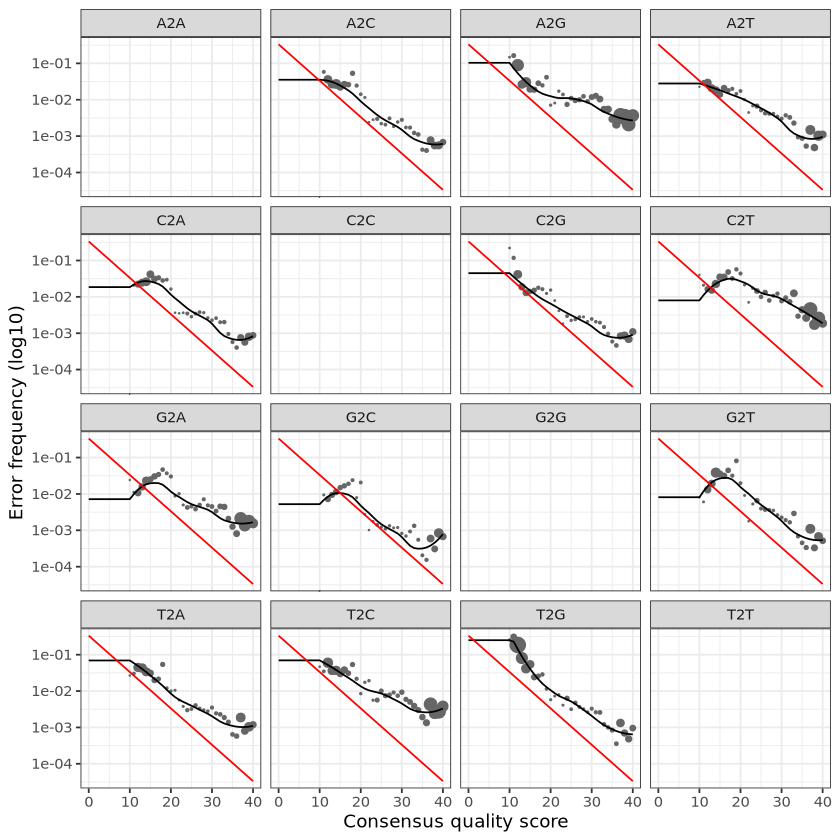

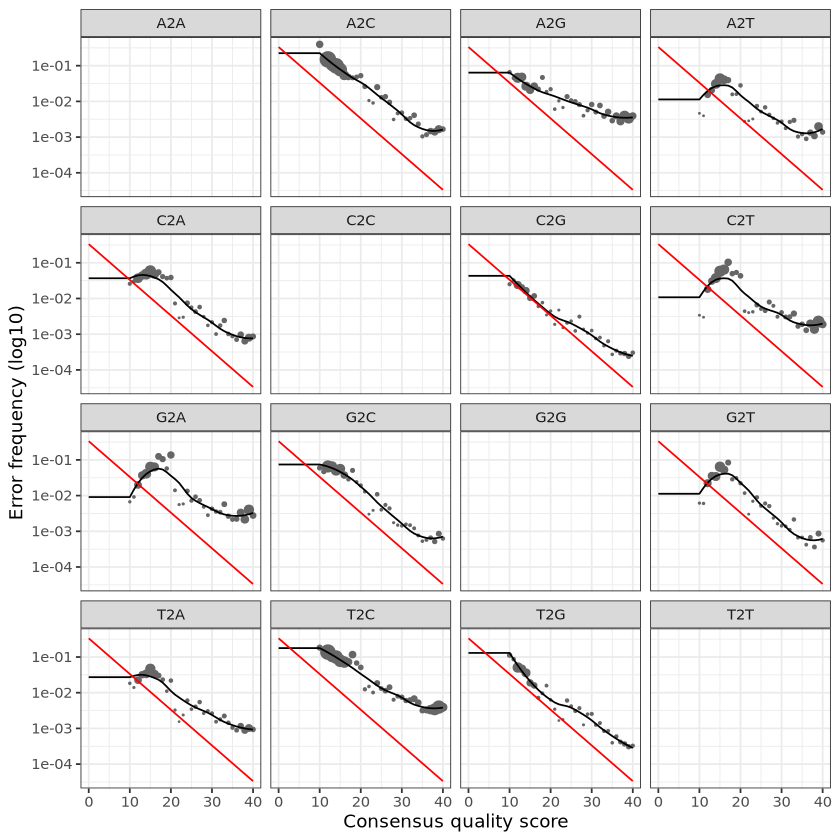

In [5]:
err_for_reads <- learnErrors(for_reads, multithread=snakemake@threads)
plotErrors(err_for_reads, nominalQ=TRUE)

err_rev_reads <- learnErrors(rev_reads, multithread=snakemake@threads)
plotErrors(err_rev_reads, nominalQ=TRUE)

# Deduplication

In [6]:
derep_for <- derepFastq(for_reads, verbose=F)
derep_rev <- derepFastq(rev_reads, verbose=F)

# AVSs calling

In [29]:
dada_for <- dada(derep_for, err=err_for_reads, pool=F, multithread=snakemake@threads)
dada_rev <- dada(derep_rev, err=err_rev_reads, pool=F, multithread=snakemake@threads)

Sample 1 - 44586 reads in 15107 unique sequences.
Sample 2 - 23352 reads in 10467 unique sequences.
Sample 3 - 31258 reads in 13011 unique sequences.
Sample 4 - 28300 reads in 11556 unique sequences.
Sample 5 - 38490 reads in 16478 unique sequences.
Sample 1 - 44586 reads in 25243 unique sequences.
Sample 2 - 23352 reads in 13973 unique sequences.
Sample 3 - 31258 reads in 15513 unique sequences.
Sample 4 - 28300 reads in 19834 unique sequences.
Sample 5 - 38490 reads in 17074 unique sequences.


In [51]:
sapply(dada_for, function(y) sum(getUniques(y)))

SRR32393053_R1.fastq.gz SRR32393054_R1.fastq.gz SRR32393055_R1.fastq.gz 
                  44187                   23015                   30633 
SRR32393056_R1.fastq.gz SRR32393057_R1.fastq.gz 
                  28055                   37948

# Merging pair-ended reads

In [8]:
merged_amplicons <- mergePairs(
    dada_for, derep_for, 
    dada_rev, derep_rev, 
    trimOverhang=TRUE, 
    minOverlap=12
)

In [9]:
names(merged_amplicons) <- sapply(strsplit(names(merged_amplicons), "_"), `[`, 1)
names(merged_amplicons)
class(merged_amplicons$SRR32393053)
length(merged_amplicons$SRR32393053$abundance)

[1] "SRR32393053" "SRR32393054" "SRR32393055" "SRR32393056" "SRR32393057"

[1] "data.frame"

[1] 331

# Counts table

In [10]:
seqtab <- makeSequenceTable(merged_amplicons)
class(seqtab)
dim(seqtab)

[1] "matrix" "array"

[1]    5 1173

# Chimera removal 

In [11]:
seqtab.nochim <- removeBimeraDenovo(seqtab, verbose=T)
sum(seqtab.nochim)/sum(seqtab) 

Identified 548 bimeras out of 1173 input sequences.



[1] 0.97414

## Taxonomy with DECIPHER

Use pertained SILVA r138.2 v2 set providing on [DECIPHER Downloads page](https://decipher.codes/Downloads.html)

In [12]:
load('resources/SILVA_SSU_r138.2_v2.RData')

In [13]:
fas <- DNAStringSet(getSequences(seqtab.nochim))

In [16]:
ids <- IdTaxa(fas, trainingSet, strand="top", processors=NULL, verbose=FALSE)

In [18]:
ranks <- c("domain", "phylum", "class", "order", "family", "genus", "species")
# Convert the output object of class "Taxa" to a matrix analogous to the output from assignTaxonomy
taxid <- t(sapply(ids, function(x) {
        m <- match(ranks, x$rank)
        taxa <- x$taxon[m]
        taxa[startsWith(taxa, "unclassified_")] <- NA
        taxa
}))
colnames(taxid) <- ranks
rownames(taxid) <- getSequences(seqtab.nochim)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 't': error in evaluating the argument 'X' in selecting a method for function 'sapply': object 'ids' not found


In [ ]:
dim(taxid)

[1] 625   7

# Save results

In [ ]:
# giving our seq headers more manageable names (ASV_1, ASV_2...)
asv_seqs <- colnames(seqtab.nochim)
asv_headers <- vector(dim(seqtab.nochim)[2], mode="character")

for (i in 1:dim(seqtab.nochim)[2]) {
    asv_headers[i] <- paste(">ASV", i, sep="_")
}

    # making and writing out a fasta of our final ASV seqs:
asv_fasta <- c(rbind(asv_headers, asv_seqs))
write(asv_fasta, snakemake@output$fasta)

    # count table:
asv_tab <- t(seqtab.nochim)
row.names(asv_tab) <-sub(">", "", asv_headers)
write.table(asv_tab, snakemake@output$counts, sep="\t", quote=F, col.names=NA)

    # tax table:
colnames(taxid) <- ranks
rownames(taxid) <- gsub(pattern=">", replacement="", x=asv_headers)

write.table(taxid, snakemake@output$tax, sep = "\t", quote=F, col.names=NA)